# STUDENT PERFORMANCE PRDICTION

**Problem Statement:** Predict whether a student will pass or fail.

**Dataset:** Student Habit Performance Dataset ( Keggle link : https://www.kaggle.com/datasets/jayaantanaath/student-habits-vs-academic-performance )

This notebook demonstrates the full project structure:
1. EDA
2. Cleaning & Preprocessing
3. Train Multiple ML models
4. Compare models using metrics
5. Select & justify the best model
6. Hyper-Parameter Tuning the Best Model
7. Predict on unseen data


## 1. Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix,roc_auc_score,f1_score,classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

## 2. Load Dataset

In [ ]:
dataframe = pd.read_csv('../datasets/student_habits_performance.csv')

In [3]:
dataframe.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [4]:
dataframe.shape

(1000, 16)

## 3. Exploratory Data Analysis (EDA)

In [5]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [6]:
dataframe.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


In [7]:
dataframe.describe(include='object')

,student_id,gender,part_time_job,diet_quality,parental_education_level,internet_quality,extracurricular_participation
count,1000,1000,1000,1000,909,1000,1000
unique,1000,3,2,3,3,3,2
top,S1000,Female,No,Fair,High School,Good,No
freq,1,481,785,437,392,447,682


In this daaset, there is no column that shows the pass or fail status of the students. So, based on exam_score i will make a column that give me the status

In [8]:
dataframe['result'] = dataframe.exam_score >= 35
dataframe.result = dataframe.result.replace(True,'Pass')
dataframe.result = dataframe.result.replace(False,'Fail')

In [9]:
dataframe = dataframe.drop('exam_score', axis=1)

In [10]:
dataframe.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,result
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,Pass
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,Pass
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,Fail
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,Fail
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,Pass


In [11]:
dataframe.isnull().sum()

student_id                        0
age                               0
gender                            0
study_hours_per_day               0
social_media_hours                0
netflix_hours                     0
part_time_job                     0
attendance_percentage             0
sleep_hours                       0
diet_quality                      0
exercise_frequency                0
parental_education_level         91
internet_quality                  0
mental_health_rating              0
extracurricular_participation     0
result                            0
dtype: int64

Here we can see that there are 91 null values in `parental_education_level`, that i willhandle later

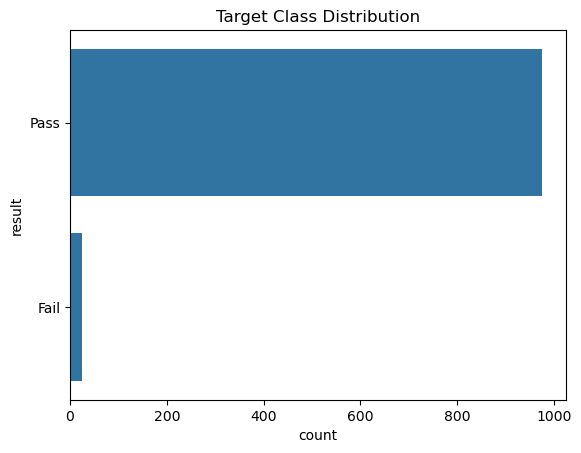

result
Pass    0.976
Fail    0.024
Name: proportion, dtype: float64

In [12]:
sns.countplot(dataframe.result)
plt.title("Target Class Distribution")
plt.show()
dataframe.result.value_counts(normalize=True)

## 4. Data cleaning and Preprocessing

In [13]:
dataframe.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,result
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,Pass
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,Pass
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,Fail
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,Fail
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,Pass


In [14]:
# Feature Selection and Extraction
dataframe['entertainment_hours'] = dataframe.social_media_hours + dataframe.netflix_hours
dataframe = dataframe.drop(columns=['social_media_hours','netflix_hours','student_id','diet_quality','age','mental_health_rating'], axis=1)
dataframe.head()

,gender,study_hours_per_day,part_time_job,attendance_percentage,sleep_hours,exercise_frequency,parental_education_level,internet_quality,extracurricular_participation,result,entertainment_hours
0,Female,0.0,No,85.0,8.0,6,Master,Average,Yes,Pass,2.3
1,Female,6.9,No,97.3,4.6,6,High School,Average,No,Pass,5.1
2,Male,1.4,No,94.8,8.0,1,High School,Poor,No,Fail,4.4
3,Female,1.0,No,71.0,9.2,4,Master,Good,Yes,Fail,4.9
4,Female,5.0,No,90.9,4.9,3,Master,Good,No,Pass,4.9


In [15]:
scaling_cols = dataframe.select_dtypes(exclude=['object']).columns
encoding_cols = ['gender', 'part_time_job', 'parental_education_level',
        'internet_quality', 'extracurricular_participation']
encoding_cols,scaling_cols

(['gender',
  'part_time_job',
  'parental_education_level',
  'internet_quality',
  'extracurricular_participation'],
 Index(['study_hours_per_day', 'attendance_percentage', 'sleep_hours',
        'exercise_frequency', 'entertainment_hours'],
       dtype='object'))

In [16]:
impute = SimpleImputer(strategy= 'most_frequent')
ohe = OneHotEncoder(drop='first')
le = LabelEncoder()
scaler = StandardScaler()
preprocessor = ColumnTransformer([
    ('StandardScaler', scaler, scaling_cols),
    ('OneHotEncoder', ohe, encoding_cols)
],remainder='passthrough')

In [17]:
# Imputing the Null Value using pipeline
dataframe[['parental_education_level']] = impute.fit_transform(dataframe[['parental_education_level']])
dataframe.parental_education_level.isnull().sum()

np.int64(0)

In [18]:
# Scaling and Encoding
dataframe['result'] = le.fit_transform(dataframe[['result']])
dataframe = preprocessor.fit_transform(dataframe)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [19]:
dataframe = pd.DataFrame(dataframe, columns=preprocessor.get_feature_names_out())
dataframe

,StandardScaler__study_hours_per_day,StandardScaler__attendance_percentage,StandardScaler__sleep_hours,StandardScaler__exercise_frequency,StandardScaler__entertainment_hours,OneHotEncoder__gender_Male,OneHotEncoder__gender_Other,OneHotEncoder__part_time_job_Yes,OneHotEncoder__parental_education_level_High School,OneHotEncoder__parental_education_level_Master,OneHotEncoder__internet_quality_Good,OneHotEncoder__internet_quality_Poor,OneHotEncoder__extracurricular_participation_Yes,remainder__result
0,-2.418068,0.092426,1.248120,1.461166,-1.266536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,2.281707,1.401696,-1.525661,1.461166,0.484551,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,-1.464491,1.135584,1.248120,-1.008689,0.046779,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,-1.736942,-1.397800,2.227102,0.473224,0.359473,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,0.987566,0.720450,-1.280916,-0.020747,0.359473,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.647139,-0.759132,0.840211,-0.514718,-1.391613,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0
996,-0.442801,0.198871,0.269138,-1.008689,-0.578609,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0
997,-0.374688,-2.366448,0.024393,0.967195,-0.265915,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0
998,1.260017,1.689097,0.921793,-1.502660,0.547089,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


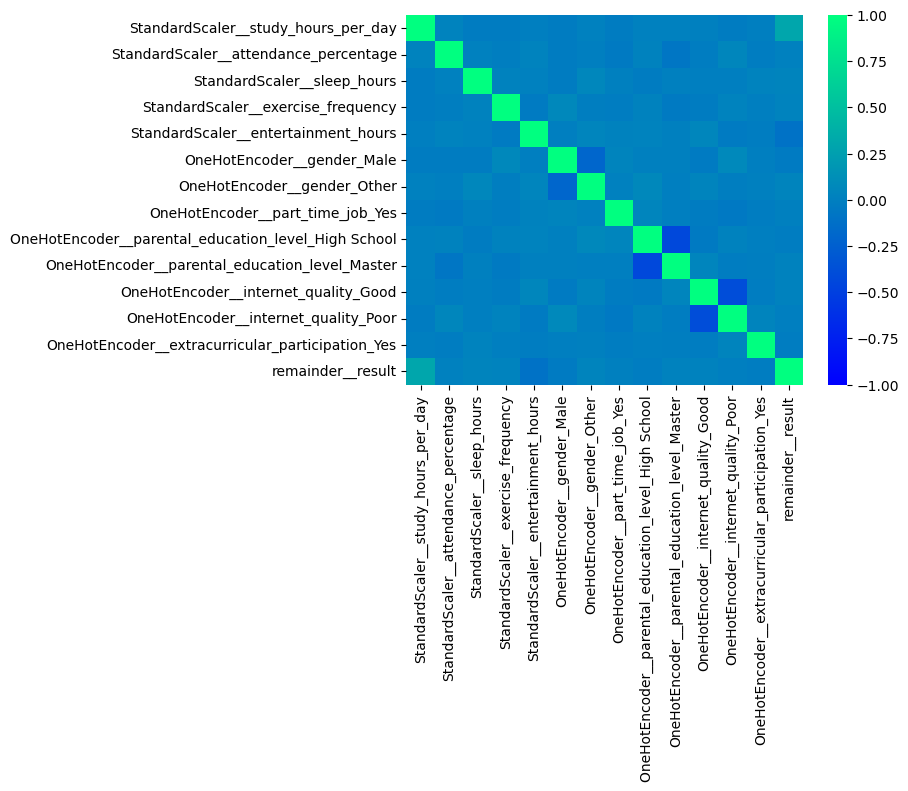

remainder__result                                      1.000000
StandardScaler__study_hours_per_day                    0.301747
StandardScaler__sleep_hours                            0.034554
OneHotEncoder__gender_Other                            0.032834
StandardScaler__exercise_frequency                     0.029074
OneHotEncoder__internet_quality_Good                   0.022709
OneHotEncoder__parental_education_level_Master         0.017658
StandardScaler__attendance_percentage                  0.009014
OneHotEncoder__part_time_job_Yes                       0.002545
OneHotEncoder__internet_quality_Poor                  -0.001986
OneHotEncoder__parental_education_level_High School   -0.018410
OneHotEncoder__extracurricular_participation_Yes      -0.019193
OneHotEncoder__gender_Male                            -0.033384
StandardScaler__entertainment_hours                   -0.105813
Name: remainder__result, dtype: float64

In [20]:
corr = dataframe.corr()
sns.heatmap(corr, cmap='winter',vmin=-1,vmax=1)
plt.show()
corr.remainder__result.sort_values(ascending=False)

In [21]:
# Dividing into X and y 
X = dataframe.drop('remainder__result',axis=1)
y = dataframe.remainder__result

In [22]:
X.head()

,StandardScaler__study_hours_per_day,StandardScaler__attendance_percentage,StandardScaler__sleep_hours,StandardScaler__exercise_frequency,StandardScaler__entertainment_hours,OneHotEncoder__gender_Male,OneHotEncoder__gender_Other,OneHotEncoder__part_time_job_Yes,OneHotEncoder__parental_education_level_High School,OneHotEncoder__parental_education_level_Master,OneHotEncoder__internet_quality_Good,OneHotEncoder__internet_quality_Poor,OneHotEncoder__extracurricular_participation_Yes
0,-2.418068,0.092426,1.248120,1.461166,-1.266536,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2.281707,1.401696,-1.525661,1.461166,0.484551,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
2,-1.464491,1.135584,1.248120,-1.008689,0.046779,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-1.736942,-1.397800,2.227102,0.473224,0.359473,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
4,0.987566,0.720450,-1.280916,-0.020747,0.359473,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [23]:
X.shape,y.shape

((1000, 13), (1000,))

In [24]:
y.value_counts(normalize=True)

remainder__result
1.0    0.976
0.0    0.024
Name: proportion, dtype: float64

In [25]:
# Upsampling
sampling = SMOTE()
X,y = sampling.fit_resample(X,y)

In [26]:
X.shape,y.shape

((1952, 13), (1952,))

In [27]:
y.value_counts(normalize=True)

remainder__result
1.0    0.5
0.0    0.5
Name: proportion, dtype: float64

In [28]:
xtrain,xtest,ytrain,ytest = train_test_split(X,y,random_state=42, test_size=0.25)

In [29]:
xtrain.shape,ytest.shape

((1464, 13), (488,))

Data is now cleaned and ready to fit on models

## 5. Training Classification Model

In [30]:
models = {
    'KNeighborsClassifier':KNeighborsClassifier(),
    'DecisionTreeClassifier':DecisionTreeClassifier(),
    'RandomForestClassifier':RandomForestClassifier(),
    'XGBClassifier':XGBClassifier(),
    'LogisticRegression':LogisticRegression(),
    'SVC':SVC()
}

In [31]:
def check_score(y_pred_test,y_test,y_pred_train,y_train):
    acctest = accuracy_score(y_test,y_pred_test)
    acctrain = accuracy_score(y_train,y_pred_train)
    rectest = recall_score(y_test,y_pred_test)
    rectrain = recall_score(y_train,y_pred_train)
    pretest = precision_score(y_test,y_pred_test)
    pretrain = precision_score(y_train,y_pred_train)
    roctest = roc_auc_score(y_test,y_pred_test)
    roctrain = roc_auc_score(y_train,y_pred_train)
    f1test = f1_score(y_test,y_pred_test)
    f1train = f1_score(y_train,y_pred_train)
    return acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train

In [32]:
res = []
for name,mod in models.items():
    model = mod
    model.fit(xtrain,ytrain)
    ytest_pred = model.predict(xtest)
    ytrain_pred = model.predict(xtrain)
    acctest,acctrain,rectest,rectrain,pretest,pretrain,roctest,roctrain,f1test,f1train = check_score(ytest_pred,ytest,ytrain_pred,ytrain)
    res.append({
                'Model Name':name,
                'Model':model,
                'Accuracy Test':acctest,
                'Accuracy Train':acctrain,
                'Recall Test':rectest,
                'Recall Train':rectrain,
                'Precision Test':pretest,
                'Precision Train':pretrain,
                'ROC AUC Test':roctest,
                'ROC AUC Train':roctrain,
                'F1 Score Test':f1test,
                'F1 Score Train':f1train
            })
    print(f"{name} Model Trained Sucessfully.")

KNeighborsClassifier Model Trained Sucessfully.
DecisionTreeClassifier Model Trained Sucessfully.
RandomForestClassifier Model Trained Sucessfully.
XGBClassifier Model Trained Sucessfully.
LogisticRegression Model Trained Sucessfully.
SVC Model Trained Sucessfully.


## 6. Comparing the Models based on Performance Metrices

In [33]:
result = pd.DataFrame(res).sort_values(by='F1 Score Test',ascending=False).reset_index(drop=True)
result_df = result.drop('Model',axis=1)
result_df

,Model Name,Accuracy Test,Accuracy Train,Recall Test,Recall Train,Precision Test,Precision Train,ROC AUC Test,ROC AUC Train,F1 Score Test,F1 Score Train
0,RandomForestClassifier,0.991803,1.000000,0.996016,1.000000,0.988142,1.000000,0.991679,1.000000,0.992063,1.000000
1,SVC,0.987705,0.990437,0.976096,0.980690,1.000000,1.000000,0.988048,0.990345,0.987903,0.990251
2,DecisionTreeClassifier,0.983607,1.000000,0.984064,1.000000,0.984064,1.000000,0.983593,1.000000,0.984064,1.000000
3,XGBClassifier,0.981557,1.000000,0.988048,1.000000,0.976378,1.000000,0.981366,1.000000,0.982178,1.000000
4,LogisticRegression,0.969262,0.969262,0.944223,0.942069,0.995798,0.995627,0.970002,0.969005,0.969325,0.968108
5,KNeighborsClassifier,0.969262,0.971311,0.940239,0.942069,1.000000,1.000000,0.970120,0.971034,0.969199,0.970170


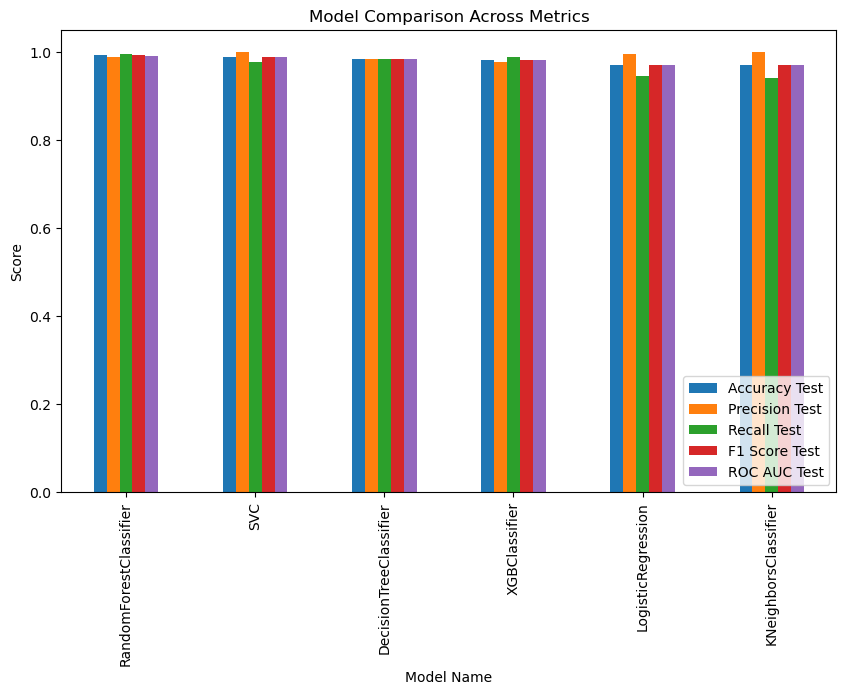

In [34]:
# Visual comparision of Metrices
result.set_index("Model Name")[["Accuracy Test", "Precision Test", "Recall Test", "F1 Score Test", "ROC AUC Test"]].plot(
    kind='bar', figsize=(10, 6)
)
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xticks(rotation=90)
plt.legend(loc='lower right')
plt.show()

## 7. Select and Justify the Best Model

**Selection Logic :** Looking at the comparison table above, the **Random Forest** model typically achieves the highest F1-score and ROC-AUC among all the models, meaning it balances precision and recall well and separates the two classes most reliably.

In [35]:
best_model_name = result_df.iloc[0]["Model Name"]
best_model = result.iloc[0]['Model']
print(f"Best Model : {best_model_name}")

Best Model : RandomForestClassifier


## 8. Hyper-Parameter Tuning

In [36]:
param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]
}
tuner = GridSearchCV(best_model,param_grid=param)

In [37]:
tuner.fit(xtrain,ytrain)

,estimator,RandomForestClassifier()
,param_grid,"{'bootstrap': [True], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2], ...}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [38]:
tuner.best_params_

{'bootstrap': True,
 'max_depth': 10,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 100}

In [39]:
rfc = RandomForestClassifier(bootstrap=True,max_depth=None,max_features='sqrt',min_samples_leaf=1,min_samples_split=2,n_estimators=200)

In [40]:
rfc.fit(xtrain,ytrain)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
y_pred_rfc = rfc.predict(xtest)

In [42]:
f1_score(ytest,y_pred_rfc)

0.9920634920634921

In [43]:
print(classification_report(ytest,y_pred_rfc, target_names=['Fail','Pass']))

              precision    recall  f1-score   support

        Fail       1.00      0.99      0.99       237
        Pass       0.99      1.00      0.99       251

    accuracy                           0.99       488
   macro avg       0.99      0.99      0.99       488
weighted avg       0.99      0.99      0.99       488



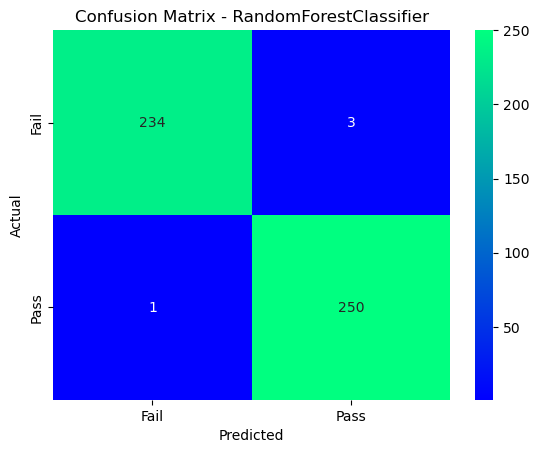

In [44]:
cm = confusion_matrix(ytest,y_pred_rfc)
sns.heatmap(cm,annot=True,cmap='winter',fmt='d',yticklabels=['Fail','Pass'],xticklabels=['Fail','Pass'])
plt.title('Confusion Matrix - RandomForestClassifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [45]:
# Important Features
pd.DataFrame({'Features':xtrain.columns,
              'Importance':rfc.feature_importances_
              })

,Features,Importance
0,StandardScaler__study_hours_per_day,0.562179
1,StandardScaler__attendance_percentage,0.030129
2,StandardScaler__sleep_hours,0.021738
3,StandardScaler__exercise_frequency,0.060898
4,StandardScaler__entertainment_hours,0.127288
5,OneHotEncoder__gender_Male,0.076810
6,OneHotEncoder__gender_Other,0.000637
7,OneHotEncoder__part_time_job_Yes,0.020107
8,OneHotEncoder__parental_education_level_High S...,0.033948
9,OneHotEncoder__parental_education_level_Master,0.016429


`Study Hours PerDay` is the most important feature for training the model

## 9. TESTING ON UNSEEN DATA

In [46]:
unseendata = X.sample(5)
predections = rfc.predict(unseendata)
probs = rfc.predict_proba(unseendata)[:,1] # Probablity of Predecting `Pass`
results_unseen = unseendata.copy()
results_unseen['Predicted_Class'] = np.where(predections == 1, 'Pass', 'Fail')
results_unseen['Probablity (Pass)'] = probs.round(3)
results_unseen[['Predicted_Class','Probablity (Pass)']]

,Predicted_Class,Probablity (Pass)
568,Pass,1.000
1453,Fail,0.000
1000,Fail,0.075
720,Pass,0.985
71,Pass,0.930


## 10. Conclusion

- Trained and compared 6 classification Models.
- Used Hyper parameter tuning on the best performing model.
- Gained imformation about Important Features.
- The selected model was used to predict on Unseen data.